# Análise Exploratória sobre Fatores Associados ao Tratamento de Saúde Mental em Jovens

## 1. DEFINIÇÃO DO PROBLEMA

## Definição do Problema

A saúde mental tem se tornado um tema cada vez mais relevante, especialmente entre jovens e adultos. Este trabalho tem como objetivo analisar fatores que influenciam a busca por tratamento de saúde mental, utilizando dados de uma pesquisa realizada com profissionais da área de tecnologia.

O foco será identificar padrões e relações entre variáveis como idade, gênero, ambiente de trabalho e histórico familiar com a decisão de buscar tratamento.

Trata-se de um problema de aprendizado supervisionado, com foco em análise exploratória de dados.

Premissas:
- A variável "treatment" indica se o indivíduo já buscou tratamento.
- A idade será utilizada para filtrar o público jovem.

Restrição:
- O dataset não representa toda a população, sendo limitado ao contexto da área de tecnologia.

##2. IMPORTAÇÃO E LEITURA DOS DADOS

In [71]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
import os

# Configuração visual
sns.set(style="whitegrid")

# Download do dataset
path = kagglehub.dataset_download("osmi/mental-health-in-tech-survey")

# Verificar arquivos disponíveis
print("Arquivos no diretório:", os.listdir(path))

# Selecionar automaticamente o arquivo CSV
files = os.listdir(path)
csv_file = [f for f in files if f.endswith('.csv')][0]

# Carregar os dados
df = pd.read_csv(f"{path}/{csv_file}")

# Visualizar primeiras linhas
df.head()

Arquivos no diretório: ['survey.csv']


,Timestamp,Age,Gender,Country,state,self_employed,family_history,treatment,work_interfere,no_employees,...,leave,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical,obs_consequence,comments
0,2014-08-27 11:29:31,37,Female,United States,IL,NaN,No,Yes,Often,6-25,...,Somewhat easy,No,No,Some of them,Yes,No,Maybe,Yes,No,NaN
1,2014-08-27 11:29:37,44,M,United States,IN,NaN,No,No,Rarely,More than 1000,...,Don't know,Maybe,No,No,No,No,No,Don't know,No,NaN
2,2014-08-27 11:29:44,32,Male,Canada,NaN,NaN,No,No,Rarely,6-25,...,Somewhat difficult,No,No,Yes,Yes,Yes,Yes,No,No,NaN
3,2014-08-27 11:29:46,31,Male,United Kingdom,NaN,NaN,Yes,Yes,Often,26-100,...,Somewhat difficult,Yes,Yes,Some of them,No,Maybe,Maybe,No,Yes,NaN
4,2014-08-27 11:30:22,31,Male,United States,TX,NaN,No,No,Never,100-500,...,Don't know,No,No,Some of them,Yes,Yes,Yes,Don't know,No,NaN


### Importação e Leitura dos Dados

Os dados foram obtidos a partir da plataforma Kaggle, utilizando a biblioteca kagglehub para download automatizado.

Após o download, foi realizada a verificação dos arquivos disponíveis no diretório e a seleção automática do arquivo no formato CSV.

Em seguida, os dados foram carregados utilizando a biblioteca pandas, permitindo a visualização inicial das primeiras linhas do dataset.

## 2. 1 TRADUÇÃO DO DF PARA PORTUGUÊS

In [54]:
# Tradução das Colunas
df.rename(columns={
    'Timestamp': 'Data',
    'Age': 'idade',
    'Gender': 'genero',
    'Country': 'pais',
    'state': 'estado',
    'self_employed': 'autonomo',
    'family_history': 'historico_familiar',
    'treatment': 'tratamento',
    'work_interfere': 'interferencia_trabalho',
    'no_employees': 'num_funcionarios',
    'remote_work': 'trabalho_remoto',
    'tech_company': 'empresa_tech',
    'benefits': 'beneficios',
    'care_options': 'opcoes_cuidado',
    'wellness_program': 'programa_bem_estar',
    'seek_help': 'busca_ajuda',
    'anonymity': 'anonimato',
    'leave': 'licenca',
    'mental_health_consequence': 'consequencia_saude_mental',
    'phys_health_consequence': 'consequencia_saude_fisica',
    'coworkers': 'colegas',
    'supervisor': 'supervisor',
    'mental_health_interview': 'entrevista_saude_mental',
    'phys_health_interview': 'entrevista_saude_fisica',
    'mental_vs_physical': 'mental_vs_fisico',
    'obs_consequence': 'observacoes_consequencia'
}, inplace=True)

#Tradução das Linhas S/N

df['tratamento'] = df['tratamento'].map({'Yes': 'Sim', 'No': 'Não'})
df['historico_familiar'] = df['historico_familiar'].map({'Yes': 'Sim', 'No': 'Não'})
df['trabalho_remoto'] = df['trabalho_remoto'].map({'Yes': 'Sim', 'No': 'Não'})
df['empresa_tech'] = df['empresa_tech'].map({'Yes': 'Sim', 'No': 'Não'})

#Tradução das colunas gênero

df['genero'] = df['genero'].str.lower().str.strip()

df['genero'] = df['genero'].replace({
    'male': 'Masculino',
    'm': 'Masculino',
    'female': 'Feminino',
    'f': 'Feminino'
})

# Outros valores viram "Outros"
df['genero'] = df['genero'].apply(
    lambda x: x if x in ['Masculino', 'Feminino'] else 'Outros'
)

## 2. 2 TRATAMENTO INICIAL

In [55]:
# Limpeza de dados
df = df[(df['idade'] <= 80) & (df['idade'] >= 0)]

# Remover colunas irrelevantes
df.drop(columns=['comments'], inplace=True)

# Converter a coluna de data para o formato datetime
df['Data'] = pd.to_datetime(df['Data']).dt.date

##3. ANÁLISE INICIAL

In [56]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
Index: 1254 entries, 0 to 1258
Data columns (total 26 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   Data                       1254 non-null   object
 1   idade                      1254 non-null   int64 
 2   genero                     1254 non-null   object
 3   pais                       1254 non-null   object
 4   estado                     741 non-null    object
 5   autonomo                   1236 non-null   object
 6   historico_familiar         1254 non-null   object
 7   tratamento                 1254 non-null   object
 8   interferencia_trabalho     991 non-null    object
 9   num_funcionarios           1254 non-null   object
 10  trabalho_remoto            1254 non-null   object
 11  empresa_tech               1254 non-null   object
 12  beneficios                 1254 non-null   object
 13  opcoes_cuidado             1254 non-null   object
 14  programa_bem_

Data                           0
idade                          0
genero                         0
pais                           0
estado                       513
autonomo                      18
historico_familiar             0
tratamento                     0
interferencia_trabalho       263
num_funcionarios               0
trabalho_remoto                0
empresa_tech                   0
beneficios                     0
opcoes_cuidado                 0
programa_bem_estar             0
busca_ajuda                    0
anonimato                      0
licenca                        0
consequencia_saude_mental      0
consequencia_saude_fisica      0
colegas                        0
supervisor                     0
entrevista_saude_mental        0
entrevista_saude_fisica        0
mental_vs_fisico               0
observacoes_consequencia       0
dtype: int64

O dataset possui diversas variáveis categóricas e numéricas.
Observa-se a presença de valores ausentes, especialmente em variáveis relacionadas ao ambiente de trabalho.

Esses dados precisarão ser tratados na etapa de pré-processamento.

##4. FILTRO POR IDADE

In [57]:
# Filtrar jovens (até 25 anos)
df_jovens = df[df['idade'] <= 25]

df_jovens.shape

(220, 26)

In [58]:
# Filtrar adultos (26 a 60 anos)
df_adultos = df[(df['idade'] > 25) & (df['idade'] < 60)]

df_adultos.shape

(1028, 26)

In [59]:
# Filtrar idosos (acima de 60 anos)
df_idosos = df[df['idade'] >= 60]

df_idosos.shape

(6, 26)

##5. DISTRIBUIÇÃO DE IDADE

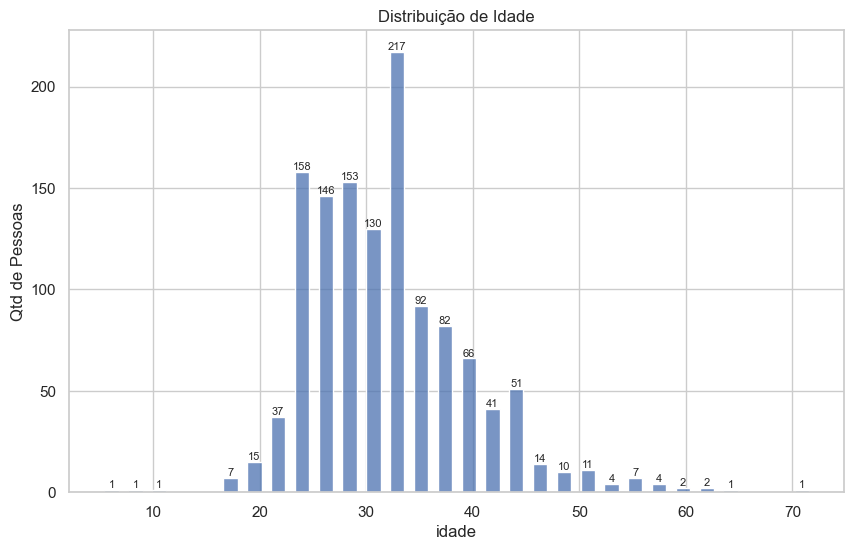

In [60]:
plt.figure(figsize=(10,6))
ax = sns.histplot(df['idade'], bins=30, shrink=0.6)

for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.text(
            p.get_x() + p.get_width() / 2,
            height,
            int(height),
            ha='center',
            va='bottom',
            fontsize=8
        )

plt.title('Distribuição de Idade')
plt.ylabel('Qtd de Pessoas')
plt.show()

Observa-se que a maioria dos respondentes está concentrada entre 20 e 35 anos.
Há presença de valores extremos, indicando possíveis outliers que podem impactar a análise.

## 6.TRATAMENTO

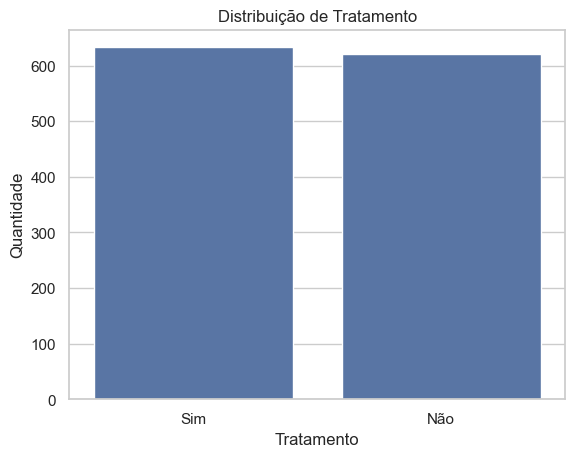

In [61]:
sns.countplot(x='tratamento', data=df)
plt.title('Distribuição de Tratamento')
plt.ylabel('Quantidade')
plt.xlabel('Tratamento')
plt.show()

A variável de tratamento apresenta distribuição relativamente equilibrada, permitindo análises sem necessidade imediata de balanceamento.

## 7.IDADE vs TRATAMENTO

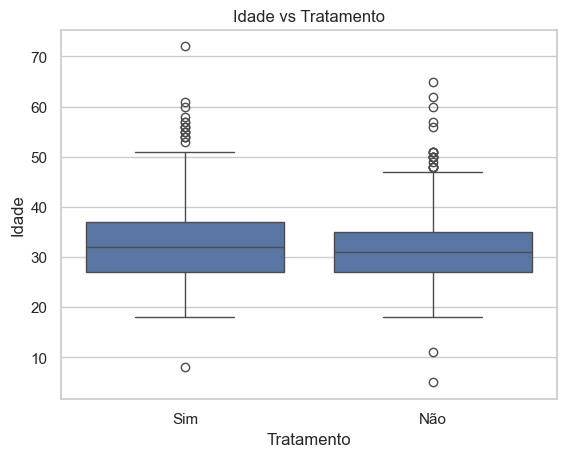

In [62]:
sns.boxplot(x='tratamento', y='idade', data=df)
plt.title('Idade vs Tratamento')
plt.ylabel('Idade')
plt.xlabel('Tratamento')
plt.show()

Indivíduos que buscaram tratamento apresentam uma leve variação na distribuição de idade, sugerindo possíveis diferenças comportamentais entre grupos.

## 8.GENERO vs TRATAMENTO

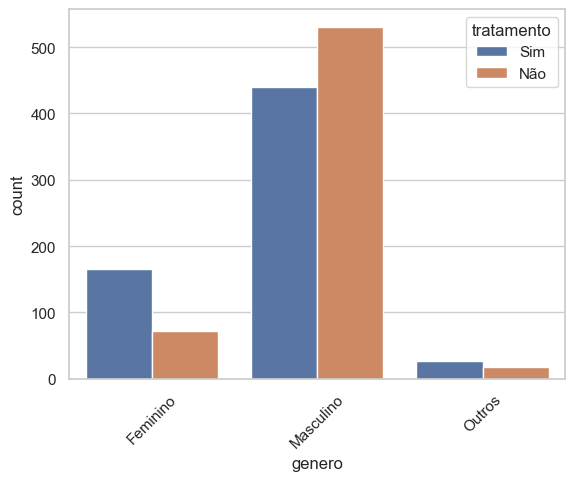

In [63]:
sns.countplot(x='genero', hue='tratamento', data=df)
plt.xticks(rotation=45)
plt.show()

Observa-se diferença na proporção de busca por tratamento entre os gêneros, o que pode indicar fatores sociais ou culturais envolvidos.

##9. PRÉ-PROCESSAMENTO
### Tratar valores faltantes

In [64]:
df = df.dropna()

### Converter variáveis

In [65]:
df['tratamento'] = df['tratamento'].map({'Yes': 1, 'No': 0})

### One-hot encoding

In [66]:
df = pd.get_dummies(df, drop_first=True)

Foram removidos valores nulos para garantir consistência dos dados.
A variável alvo foi convertida para formato numérico e variáveis categóricas foram transformadas utilizando one-hot encoding.

##10. MATRIZ DE CORRELAÇÃO

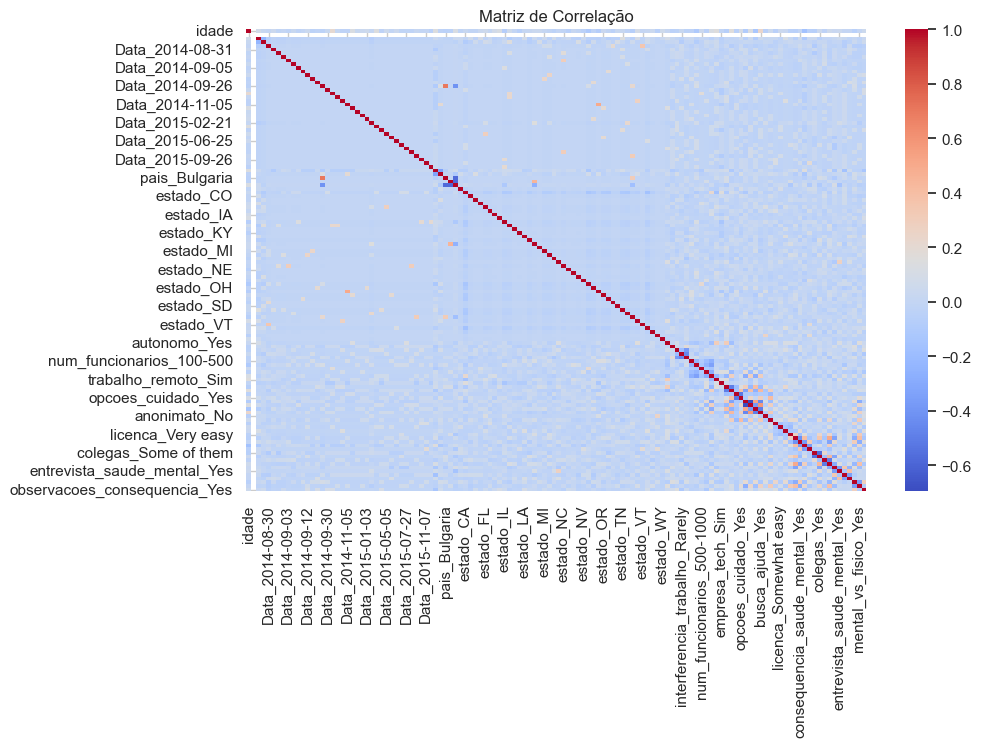

In [67]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), cmap='coolwarm'
            #, annot=True, fmt=".2f"
            )
plt.title('Matriz de Correlação')
plt.show()

A matriz de correlação permite identificar relações entre variáveis, destacando possíveis fatores associados à busca por tratamento.

## 11. CONCLUSÃO

A análise indicou que fatores como idade, gênero e ambiente de trabalho possuem relação com a busca por tratamento de saúde mental.

Além disso, foi possível observar padrões que sugerem a influência de aspectos sociais e culturais nesse comportamento.

Como trabalhos futuros, recomenda-se a aplicação de modelos preditivos para aprofundar a análise.

In [70]:
import os

print("O arquivo foi salvo no diretório atual:", os.getcwd())
df.to_csv('dados_limpos.csv', index=False)

O arquivo foi salvo no diretório atual: c:\Users\Admin\Documents\GitHub\MPV_Analise_Dados_Boas_Praticas
